#  Fertility Chance Prediction
### Predicting a patient's fertility chance: **High / Moderate / Low**
A patient-friendly, clinically appropriate framing — focused on *potential*, not *risk*.

| Label | Meaning |
|---|---|
|  **High Chance** | Strong fertility indicators — conception likely with normal effort |
| **Moderate Chance** | Some concerns present — monitoring or mild intervention may help |
|  **Low Chance** | Multiple factors affecting fertility — specialist consultation recommended |

> This tool is for **educational screening only**. Clinical decisions must always involve a qualified reproductive specialist.



```
# This is formatted as code
 Install & Import

In [1]:
!pip install imbalanced-learn shap xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, f1_score, accuracy_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

sns.set_theme(style="whitegrid", palette="muted")

# Consistent colour scheme throughout — green/amber/red = high/moderate/low
CHANCE_COLORS  = {'high':'#4caf50', 'moderate':'#ff9800', 'low':'#f44336'}
CHANCE_LABELS  = ['high', 'moderate', 'low']
CHANCE_DISPLAY = {'high':'High Chance', 'moderate':'Moderate Chance', 'low':' Low Chance'}



In [3]:
df=pd.read_csv("/content/fertility_dataset.csv")

In [ ]:
df.head(5)

,female_age,partner_age,months_trying,cycle_length,cycle_regular,ever_pregnant,live_births,miscarriages,ectopic,pcos,...,activity,sleep,stress,amh,fsh,tsh,vitd,semen_analysis,prior_infertility_dx,fertility_chance
0,30.3,35.6,12,29,1,1,0,2,0,0,...,sedentary,6.5,1,1.89,9.38,1.21,29.22,normal,both,moderate
1,36.8,40.0,26,25,0,0,0,0,0,0,...,moderate,7.8,7,NaN,6.05,1.32,NaN,normal,none,moderate
2,29.8,32.1,1,27,0,0,0,0,0,1,...,moderate,7.1,4,1.70,6.36,NaN,NaN,normal,none,high
3,36.0,38.7,19,27,1,1,1,0,0,1,...,moderate,7.8,5,0.94,NaN,NaN,37.88,unknown,none,high
4,34.5,35.8,3,25,1,1,2,0,0,0,...,moderate,5.1,7,0.22,9.76,1.87,NaN,normal,none,high


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   female_age            2000 non-null   float64
 1   partner_age           2000 non-null   float64
 2   months_trying         2000 non-null   int64  
 3   cycle_length          2000 non-null   int64  
 4   cycle_regular         2000 non-null   int64  
 5   ever_pregnant         2000 non-null   int64  
 6   live_births           2000 non-null   int64  
 7   miscarriages          2000 non-null   int64  
 8   ectopic               2000 non-null   int64  
 9   pcos                  2000 non-null   int64  
 10  endometriosis         2000 non-null   int64  
 11  thyroid               2000 non-null   int64  
 12  diabetes              2000 non-null   int64  
 13  bmi                   2000 non-null   float64
 14  smoking               2000 non-null   object 
 15  alcohol              

In [5]:
columns=['ever_pregnant','cycle_regular','ectopic','pcos','endometriosis','thyroid','diabetes']
df[columns] = df[columns].astype(bool)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   female_age            2000 non-null   float64
 1   partner_age           2000 non-null   float64
 2   months_trying         2000 non-null   int64  
 3   cycle_length          2000 non-null   int64  
 4   cycle_regular         2000 non-null   bool   
 5   ever_pregnant         2000 non-null   bool   
 6   live_births           2000 non-null   int64  
 7   miscarriages          2000 non-null   int64  
 8   ectopic               2000 non-null   bool   
 9   pcos                  2000 non-null   bool   
 10  endometriosis         2000 non-null   bool   
 11  thyroid               2000 non-null   bool   
 12  diabetes              2000 non-null   bool   
 13  bmi                   2000 non-null   float64
 14  smoking               2000 non-null   object 
 15  alcohol              

In [7]:
df.isnull().sum()

,0
female_age,0
partner_age,0
months_trying,0
cycle_length,0
cycle_regular,0
ever_pregnant,0
live_births,0
miscarriages,0
ectopic,0
pcos,0




```
# This is formatted as code
```

# Exploratory Data Analysis
Understanding what separates high-chance from low-chance patients.

Text(0.5, 0, '')

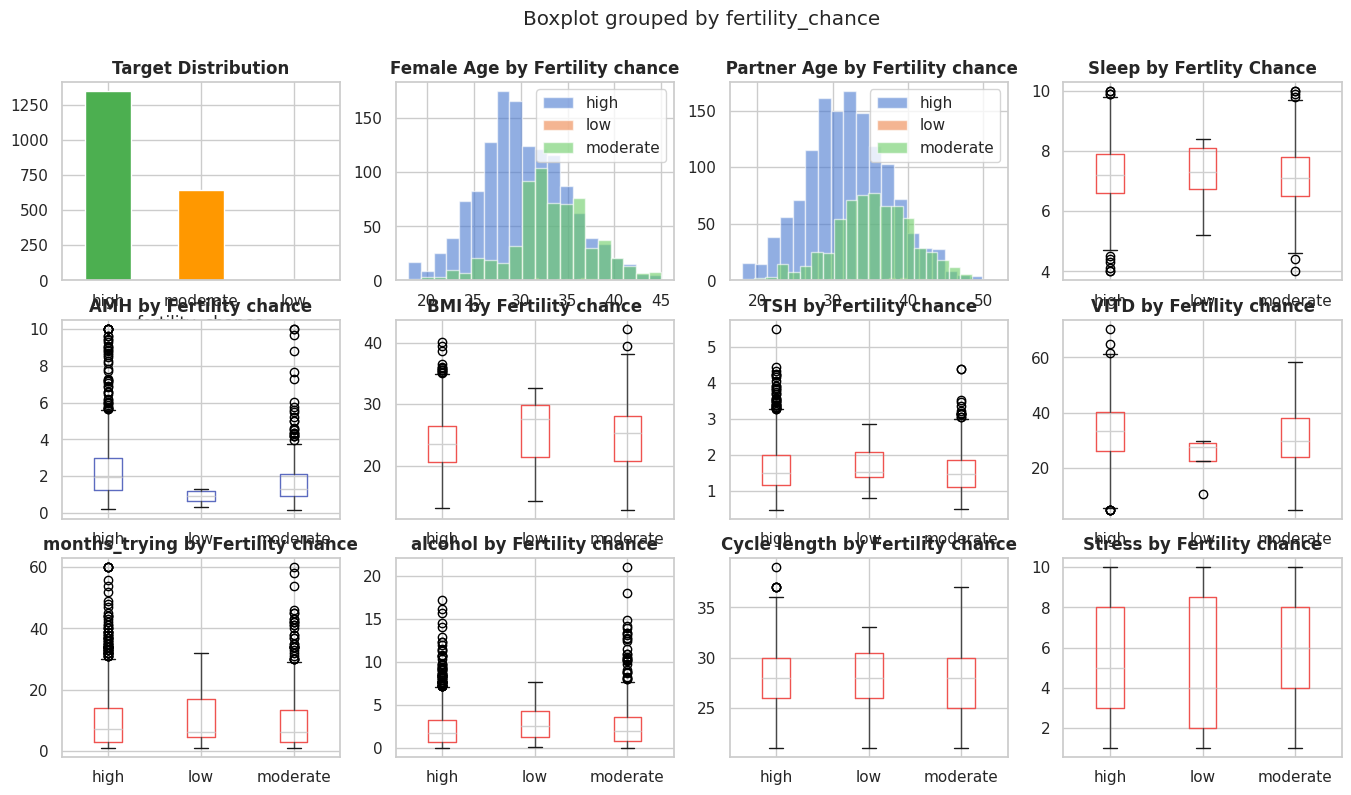

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))

# Target distribution
df['fertility_chance'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#4caf50','#ff9800','#f44336'], edgecolor='white')
axes[0,0].set_title('Target Distribution', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=0)


for risk, grp in df.groupby('fertility_chance'):
    axes[0,1].hist(grp['female_age'], bins=20, alpha=0.6, label=risk)
axes[0,1].set_title('Female Age by Fertility chance', fontweight='bold')
axes[0,1].legend()

for risk, grp in df.groupby('fertility_chance'):
    axes[0,2].hist(grp['partner_age'], bins=20, alpha=0.6, label=risk)
axes[0,2].set_title(' Partner Age by Fertility chance', fontweight='bold')
axes[0,2].legend()

df.boxplot(column='sleep', by='fertility_chance', ax=axes[0,3],
           boxprops=dict(color='#ef5350'))
axes[0,3].set_title('Sleep by Fertlity Chance', fontweight='bold')
plt.sca(axes[0,3]); plt.xlabel('')

# 4. AMH by risk
df.boxplot(column='amh', by='fertility_chance', ax=axes[1,0],
           boxprops=dict(color='#5c6bc0'))
axes[1,0].set_title('AMH by Fertility chance', fontweight='bold')
plt.sca(axes[1,0]); plt.xlabel('')

# 5. BMI by risk
df.boxplot(column='bmi', by='fertility_chance', ax=axes[1,1],
           boxprops=dict(color='#ef5350'))
axes[1,1].set_title('BMI by Fertility chance', fontweight='bold')
plt.sca(axes[1,1]); plt.xlabel('')

# TSH vy Risk
df.boxplot(column='tsh', by='fertility_chance', ax=axes[1,2],
           boxprops=dict(color='#ef5350'))
axes[1,2].set_title('TSH by Fertility chance', fontweight='bold')
plt.sca(axes[1,2]); plt.xlabel('')

df.boxplot(column='vitd', by='fertility_chance', ax=axes[1,3],
           boxprops=dict(color='#ef5350'))
axes[1,3].set_title('VITD by Fertility chance', fontweight='bold')
plt.sca(axes[1,3]); plt.xlabel('')

df.boxplot(column='months_trying', by='fertility_chance', ax=axes[2,0],
           boxprops=dict(color='#ef5350'))
axes[2,0].set_title('months_trying by Fertility chance', fontweight='bold')
plt.sca(axes[2,0]); plt.xlabel('')

df.boxplot(column='alcohol', by='fertility_chance', ax=axes[2,1],
           boxprops=dict(color='#ef5350'))
axes[2,1].set_title('alcohol by Fertility chance', fontweight='bold')
plt.sca(axes[2,1]); plt.xlabel('')

df.boxplot(column='cycle_length', by='fertility_chance', ax=axes[2,2],
           boxprops=dict(color='#ef5350'))
axes[2,2].set_title('Cycle length by Fertility chance', fontweight='bold')
plt.sca(axes[2,2]); plt.xlabel('')

df.boxplot(column='stress', by='fertility_chance', ax=axes[2,3],
           boxprops=dict(color='#ef5350'))
axes[2,3].set_title('Stress by Fertility chance', fontweight='bold')
plt.sca(axes[2,3]); plt.xlabel('')


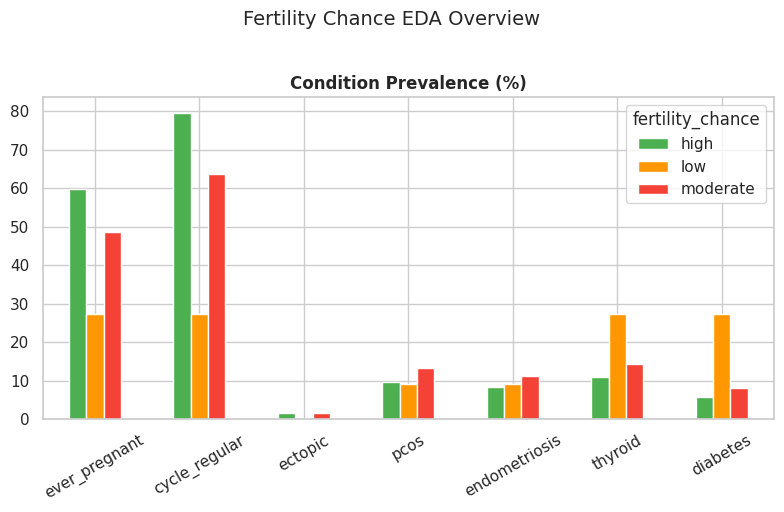

In [9]:
import matplotlib.pyplot as plt


bool_cols =['ever_pregnant','cycle_regular','ectopic','pcos','endometriosis','thyroid','diabetes']

# Make a copy and ensure 'risk' is string
tmp = df.copy()
tmp['fertility_chance'] = tmp['fertility_chance'].astype(str)

# Convert boolean columns to int (0 or 1) for mean calculation
for col in bool_cols:
    tmp[col] = tmp[col].astype(int)

# Create the figure
fig, ax = plt.subplots(figsize=(8,5))

# Plot prevalence
tmp.groupby('fertility_chance')[bool_cols].mean().mul(100).T.plot(
    kind='bar', ax=ax, color=['#4caf50','#ff9800','#f44336'])

# Customize
ax.set_title('Condition Prevalence (%)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='fertility_chance')

plt.suptitle('Fertility Chance EDA Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

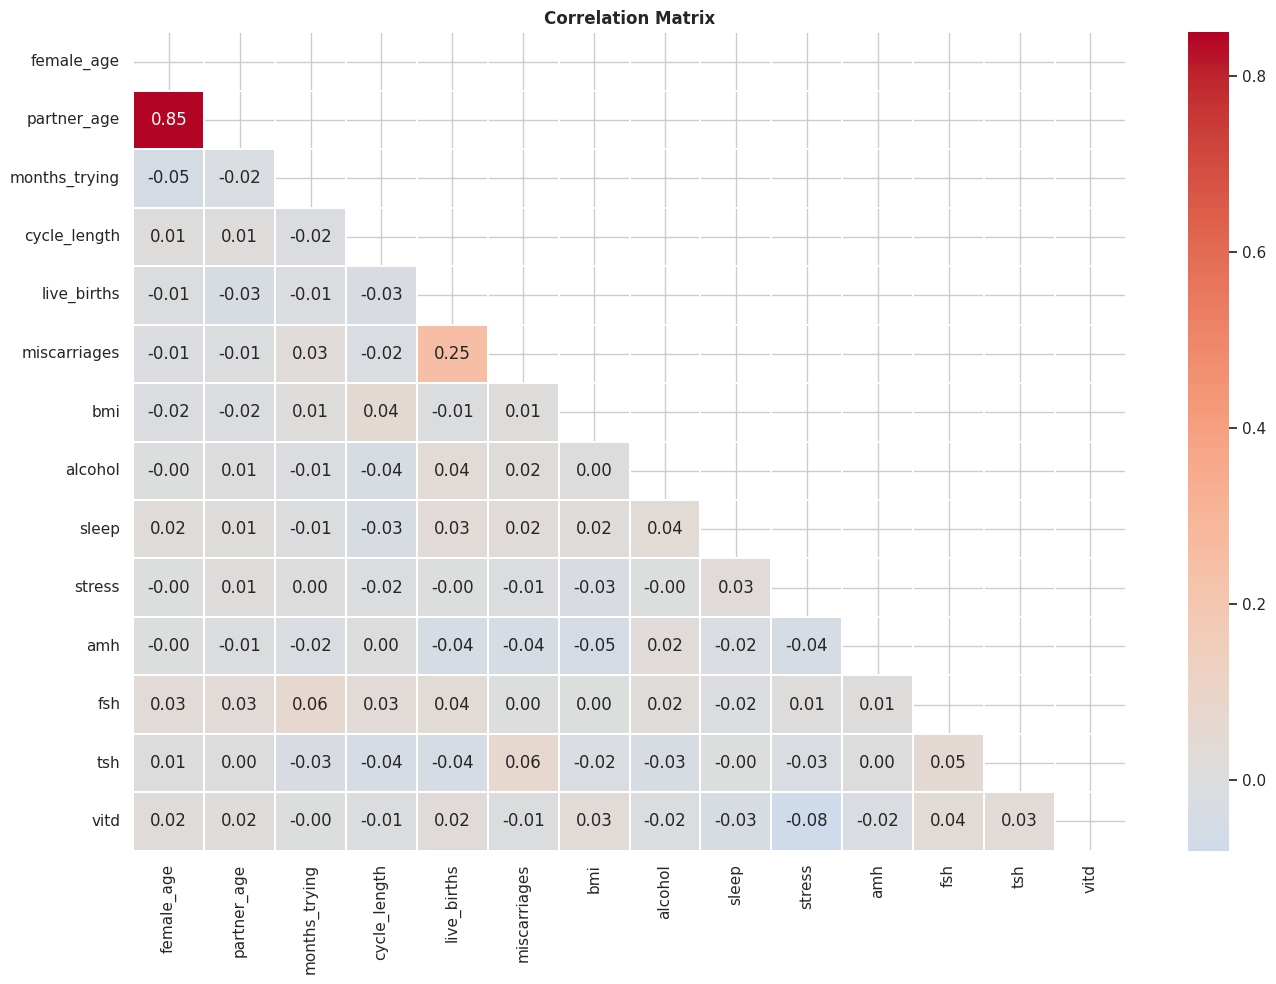

In [10]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, ax = plt.subplots(figsize=(14,10))
mask = np.triu(np.ones(len(num_cols), dtype=bool))
sns.heatmap(df[num_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.3, ax=ax)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.show()


##  Data Cleaning & Preprocessing
IQR capping → encode → feature engineering → split → KNN impute → scale → SMOTE

In [12]:
dc = df.copy()

# 1. IQR outlier capping
for col in ['bmi','alcohol','months_trying']:
    q1,q3 = dc[col].quantile([0.25,0.75])
    iqr   = q3 - q1
    dc[col] = dc[col].clip(q1 - 3*iqr, q3 + 3*iqr)

# 2. Encode categoricals
dc['smoking']              = dc['smoking'].map({'never':0,'former':1,'current':2})
dc['activity']             = dc['activity'].map({'sedentary':0,'light':1,'moderate':2,'high':3})
dc['semen_analysis']       = dc['semen_analysis'].map({'normal':2,'unknown':1,'abnormal':0})
dc['prior_infertility_dx'] = dc['prior_infertility_dx'].map({'none':2,'one_partner':1,'both':0})

# 3. Encode target  (high=2, moderate=1, low=0)
dc['target'] = dc['fertility_chance'].map({'high':2,'moderate':1,'low':0})
dc.drop(columns=['fertility_chance'], inplace=True)

# 4. Feature engineering — positive-framing features
dc['prime_age']       = ((dc['female_age'] >= 22) & (dc['female_age'] <= 32)).astype(int)
dc['healthy_bmi']     = ((dc['bmi'] >= 18.5) & (dc['bmi'] <= 25)).astype(int)
dc['good_amh']        = (dc['amh'].fillna(-1) >= 1.5).astype(int)
dc['normal_fsh']      = (dc['fsh'].fillna(99) <= 8.0).astype(int)
dc['optimal_vitd']    = (dc['vitd'].fillna(-1) >= 30).astype(int)
dc['healthy_habits']  = (dc['smoking']==0).astype(int) + (dc['alcohol']<=3).astype(int) +                         (dc['sleep']>=7).astype(int) + (dc['activity']>=2).astype(int)
dc['no_diagnosis']    = (~(dc['pcos'].astype(bool) | dc['endometriosis'].astype(bool) |
                            dc['thyroid'].astype(bool) | dc['diabetes'].astype(bool))).astype(int)

print(f"Cleaned shape: {dc.shape}")
print(f"Engineered:    prime_age, healthy_bmi, good_amh, normal_fsh,")
print(f"               optimal_vitd, healthy_habits, no_diagnosis")



Cleaned shape: (2000, 33)
Engineered:    prime_age, healthy_bmi, good_amh, normal_fsh,
               optimal_vitd, healthy_habits, no_diagnosis


In [13]:
# 5. Train/test split — BEFORE imputation (no leakage)
X = dc.drop(columns=['target'])
y = dc['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# 6. Simpleimputation (fit on train only)
imp = SimpleImputer(strategy="median", add_indicator=True)

X_tr = pd.DataFrame(imp.fit_transform(X_train), columns=imp.get_feature_names_out())
X_te = pd.DataFrame(imp.transform(X_test),      columns=imp.get_feature_names_out())

# 7. StandardScaler
sc = StandardScaler()
X_tr = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns)
X_te = pd.DataFrame(sc.transform(X_te),     columns=X_te.columns)

# 8. SMOTE to balance classes
X_bal, y_bal = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_tr, y_train)

print(f"\nTrain: {X_tr.shape}  |  Test: {X_te.shape}")
bal_counts = pd.Series(y_bal).map({2:'High',1:'Moderate',0:'Low'}).value_counts()
print(f"After SMOTE: {bal_counts.to_dict()}")
print("✅ Preprocessing complete")


Train: (1600, 36)  |  Test: (400, 36)
After SMOTE: {'Moderate': 1077, 'High': 1077, 'Low': 1077}
✅ Preprocessing complete


## Train & Compare 4 ML Models
5-fold stratified CV · Macro F1 · auto-selects winner

Model | CV F1 |  | Test F1
Logistic Regression       |   0.9337 | 0.0077 |   0.6922
Random Forest             |   0.9561 | 0.0034 |   0.7354
Gradient Boosting         |   0.9684 | 0.0067 |   0.6055
XGBoost                   |   0.9681 | 0.0062 |   0.5913

 Best model: Gradient Boosting


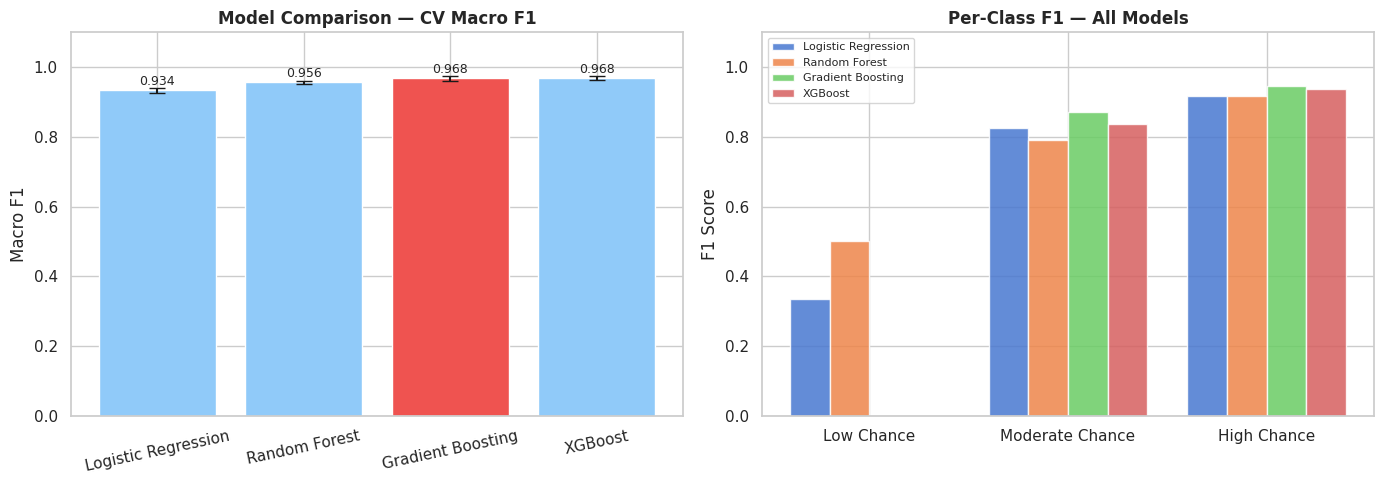

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, eval_metric='mlogloss',
                                          use_label_encoder=False, random_state=42),
}

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
res = {}

print(f"{'Model'} | {'CV F1'} |  | {'Test F1'}")

for name, mdl in models.items():
    cv_f1  = cross_val_score(mdl, X_bal, y_bal, cv=cv, scoring='f1_macro', n_jobs=-1)
    mdl.fit(X_bal, y_bal)
    y_pred = mdl.predict(X_te)
    tf1    = f1_score(y_test, y_pred, average='macro')
    res[name] = {'cv_mean':cv_f1.mean(),'cv_std':cv_f1.std(),
                 'test_f1':tf1,'model':mdl,'y_pred':y_pred}
    print(f"{name:<25} | {cv_f1.mean():>8.4f} | {cv_f1.std():>6.4f} | {tf1:>8.4f}")

best_name  = max(res, key=lambda k: res[k]['cv_mean'])
best_model = res[best_name]['model']
y_pred     = res[best_name]['y_pred']
print(f"\n Best model: {best_name}")

# Comparison chart
fig, axes = plt.subplots(1,2,figsize=(14,5))

names  = list(res.keys())
means  = [res[n]['cv_mean'] for n in names]
stds   = [res[n]['cv_std']  for n in names]
colors = ['#ef5350' if n==best_name else '#90caf9' for n in names]
bars   = axes[0].bar(names, means, yerr=stds, color=colors, capsize=6, edgecolor='white')
axes[0].set_ylim(0,1.1); axes[0].set_ylabel('Macro F1')
axes[0].set_title('Model Comparison — CV Macro F1', fontweight='bold')
axes[0].tick_params(axis='x', rotation=12)
for b,m in zip(bars,means):
    axes[0].text(b.get_x()+b.get_width()/2, m+0.015, f'{m:.3f}', ha='center', fontsize=9)

# Per-class accuracy per model
x = np.arange(3); w = 0.2
for i,(name,r) in enumerate(res.items()):
    rep = classification_report(y_test, r['y_pred'],
                                target_names=['low','moderate','high'],
                                output_dict=True)
    f1s = [rep[l]['f1-score'] for l in ['low','moderate','high']]
    axes[1].bar(x + i*w, f1s, w, label=name, alpha=0.85)
axes[1].set_xticks(x+w*1.5)
axes[1].set_xticklabels(['Low Chance','Moderate Chance','High Chance'])
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0,1.1)
axes[1].set_title('Per-Class F1 — All Models', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Model Evaluation
Confusion matrix · Per-class F1 · ROC curves · Full classification report

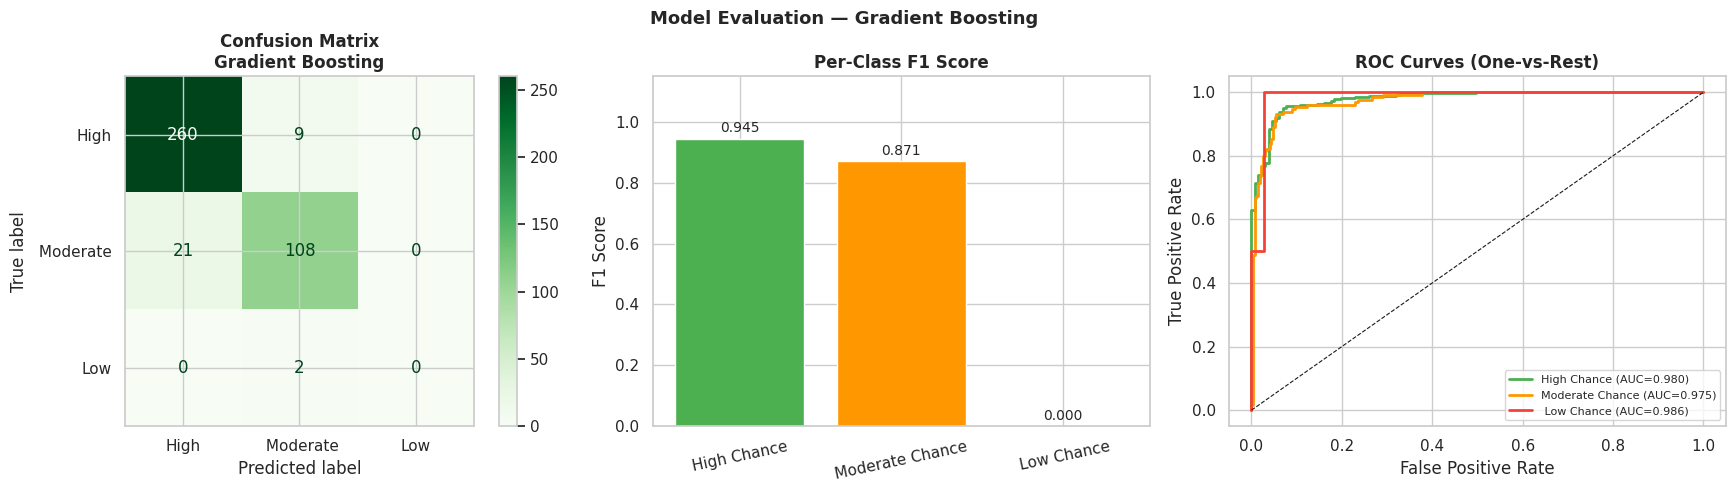


 Full Classification Report 
                 precision    recall  f1-score   support

    High Chance       0.93      0.97      0.95       269
Moderate Chance       0.91      0.84      0.87       129
     Low Chance       0.00      0.00      0.00         2

       accuracy                           0.92       400
      macro avg       0.61      0.60      0.61       400
   weighted avg       0.91      0.92      0.92       400



In [15]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
labels_ord = ['high','moderate','low']   # positive-first ordering

# 1. Confusion matrix
cm   = confusion_matrix(y_test, y_pred, labels=[2,1,0])
disp = ConfusionMatrixDisplay(cm, display_labels=['High',' Moderate','Low'])
disp.plot(ax=axes[0], cmap='Greens')
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')

# 2. Per-class F1
report = classification_report(y_test, y_pred,
                                labels=[2,1,0],
                                target_names=labels_ord,
                                output_dict=True)
f1s    = [report[l]['f1-score'] for l in labels_ord]
clrs   = [CHANCE_COLORS[l] for l in labels_ord]
bars   = axes[1].bar([CHANCE_DISPLAY[l] for l in labels_ord], f1s, color=clrs, edgecolor='white')
axes[1].set_ylim(0,1.15); axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 Score', fontweight='bold')
axes[1].tick_params(axis='x',rotation=12)
for b,v in zip(bars,f1s): axes[1].text(b.get_x()+b.get_width()/2, v+0.02,
                                         f'{v:.3f}', ha='center', fontsize=10)

# 3. ROC curves
if hasattr(best_model,'predict_proba'):
    proba = best_model.predict_proba(X_te)
    # predict_proba returns [low=0, moderate=1, high=2]
    class_map = {0:'low',1:'moderate',2:'high'}
    for i in [2,1,0]:
        fpr,tpr,_ = roc_curve((y_test==i).astype(int), proba[:,i])
        auc = roc_auc_score((y_test==i).astype(int), proba[:,i])
        lbl = class_map[i]
        axes[2].plot(fpr,tpr,color=CHANCE_COLORS[lbl],lw=2,
                     label=f'{CHANCE_DISPLAY[lbl]} (AUC={auc:.3f})')
    axes[2].plot([0,1],[0,1],'k--',lw=0.8)
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title('ROC Curves (One-vs-Rest)', fontweight='bold')
    axes[2].legend(fontsize=8)

plt.suptitle(f'Model Evaluation — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n Full Classification Report ")
print(classification_report(y_test, y_pred,
      labels=[2,1,0], target_names=['High Chance','Moderate Chance','Low Chance']))

## What Drives Fertility Chance?
Feature importance + SHAP — framed around what *helps* vs *hinders* fertility

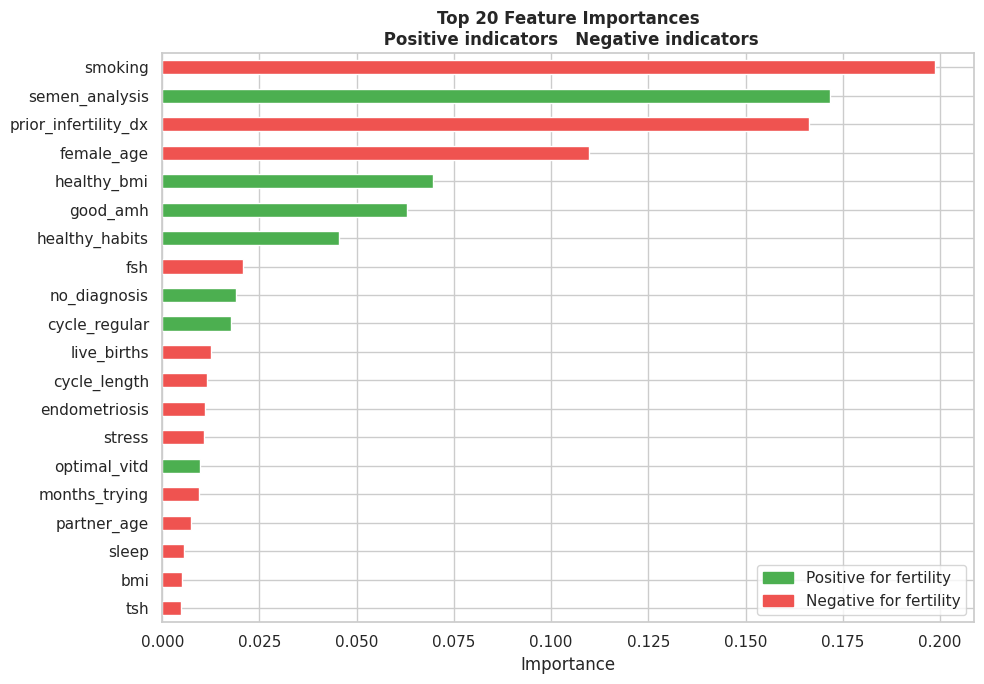

SHAP skipped: GradientBoostingClassifier is only supported for binary classification right now!


In [17]:
if hasattr(best_model,'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_,
                   index=X_tr.columns).sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10,7))
    colors_fi = ['#4caf50' if any(x in col for x in
                 ['amh','good','prime','healthy','normal','regular','vitd','semen','no_diag'])
                 else '#ef5350' for col in fi.index]
    fi.plot(kind='barh', ax=ax, color=colors_fi)
    ax.set_title('Top 20 Feature Importances\n Positive indicators   Negative indicators',
                 fontweight='bold')
    ax.set_xlabel('Importance')

    green_patch = mpatches.Patch(color='#4caf50', label='Positive for fertility')
    red_patch   = mpatches.Patch(color='#ef5350', label='Negative for fertility')
    ax.legend(handles=[green_patch, red_patch])
    plt.tight_layout(); plt.show()

# SHAP — focused on High Chance class
try:
    explainer = shap.TreeExplainer(best_model)
    sv        = explainer.shap_values(X_te.iloc[:300])
    sv_high   = sv[2] if isinstance(sv,list) else sv  # class index 2 = high chance

    print("\n SHAP — Factors most influential for HIGH fertility chance:")
    plt.figure(figsize=(11,7))
    shap.summary_plot(sv_high, X_te.iloc[:300], show=False,
                      plot_title='SHAP Values — High Fertility Chance Class')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(10,6))
    shap.summary_plot(sv_high, X_te.iloc[:300], plot_type='bar', show=False)
    plt.tight_layout(); plt.show()
    print(" SHAP complete")
except Exception as e:
    print(f"SHAP skipped: {e}")

## Patient Fertility Chance Predictor
Edit any patient profile below and re-run to get their fertility chance prediction.

**Encoding guide:**
- `smoking`: 0=never, 1=former, 2=current
- `activity`: 0=sedentary, 1=light, 2=moderate, 3=high
- `semen_analysis`: 0=abnormal, 1=unknown, 2=normal
- `prior_infertility_dx`: 0=both partners, 1=one partner, 2=none

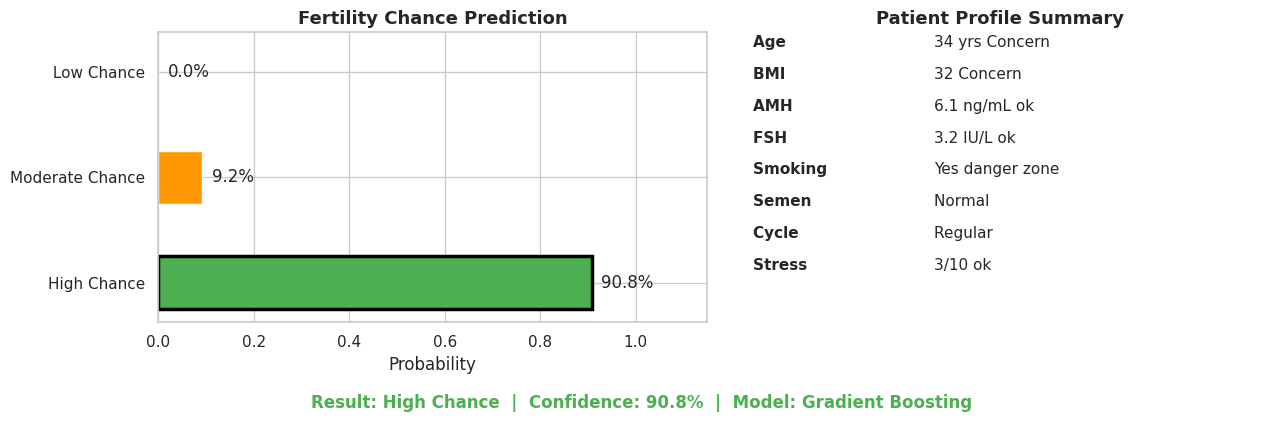


 Screening tool only — clinical decisions require a specialist.


In [34]:

patient = {
    'female_age'    : 34,    # years
    'partner_age'   : 36,
    'months_trying' : 6,     # months
    'cycle_length'  : 35,    # days
    'cycle_regular' : 1,     # 1=regular, 0=irregular
    'ever_pregnant' : 1,
    'live_births'   : 0,
    'miscarriages'  : 1,
    'ectopic'       : 0,
    'pcos'          : 1,
    'endometriosis' : 0,
    'thyroid'       : 0,
    'diabetes'      : 0,
    'bmi'           : 32,
    'smoking'       : 2,     # 0=never
    'alcohol'       : 2,
    'activity'      : 2,     # 2=moderate
    'sleep'         : 7.5,
    'stress'        : 3,
    'amh'           : 6.1,   # set np.nan if not available
    'fsh'           : 3.2,   # set np.nan if not available
    'tsh'           : 2.1,   # set np.nan if not available
    'vitd'          : 38,    # set np.nan if not available
    'semen_analysis': 2,     # 2=normal
    'prior_infertility_dx': 1 # 2=none
}
# ──────────────────────────────────────────────────────────

p = pd.DataFrame([patient])

# Engineer same features as training
p['prime_age']      = int(22 <= p['female_age'].values[0] <= 32)
p['healthy_bmi']    = int(18.5 <= p['bmi'].values[0] <= 25)
p['good_amh']       = int(p['amh'].fillna(-1).values[0] >= 1.5)
p['normal_fsh']     = int(p['fsh'].fillna(99).values[0] <= 8.0)
p['optimal_vitd']   = int(p['vitd'].fillna(-1).values[0] >= 30)
p['healthy_habits'] = (int(p['smoking'].values[0]==0) + int(p['alcohol'].values[0]<=3) +
                       int(p['sleep'].values[0]>=7) + int(p['activity'].values[0]>=2))
p['no_diagnosis']   = int(not any([p['pcos'].values[0], p['endometriosis'].values[0],
                                    p['thyroid'].values[0], p['diabetes'].values[0]]))

p_imp = pd.DataFrame(imp.transform(p[X.columns]), columns=X_tr.columns)
p_sc  = pd.DataFrame(sc.transform(p_imp),         columns=X_tr.columns)

pred  = best_model.predict(p_sc)[0]
proba = best_model.predict_proba(p_sc)[0]
# proba order matches training: index 0=low, 1=moderate, 2=high
label = {0:'low', 1:'moderate', 2:'high'}[pred]

# ── Visual result card ─────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(13,4))

# Probability bars
chance_vals = [proba[2], proba[1], proba[0]]   # high, moderate, low
chance_lbls = [CHANCE_DISPLAY['high'], CHANCE_DISPLAY['moderate'], CHANCE_DISPLAY['low']]
colors_r    = [CHANCE_COLORS['high'], CHANCE_COLORS['moderate'], CHANCE_COLORS['low']]
bars = axes[0].barh(chance_lbls, chance_vals, color=colors_r, edgecolor='white', height=0.5)
axes[0].set_xlim(0,1.15)
axes[0].set_title(f'Fertility Chance Prediction', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Probability')
for b,v in zip(bars,chance_vals):
    axes[0].text(v+0.02, b.get_y()+b.get_height()/2, f'{v:.1%}', va='center', fontsize=12)

# Highlight the predicted class
predicted_bar = bars[['high','moderate','low'].index(label)]
predicted_bar.set_edgecolor('black'); predicted_bar.set_linewidth(2.5)

# Key patient factors panel
factors = {
    'Age': f"{patient['female_age']} yrs {'Ok' if patient['female_age']<=32 else 'Concern'}",
    'BMI': f"{patient['bmi']} {'ok' if 18.5<=patient['bmi']<=25 else 'Concern'}",
    'AMH': f"{patient['amh']} ng/mL {'ok' if patient['amh']>=1.5 else 'Concern'}",
    'FSH': f"{patient['fsh']} IU/L {'ok' if patient['fsh']<=8 else 'Concern'}",
    'Smoking': f"{'Never ' if patient['smoking']==0 else 'Yes danger zone'}",
    'Semen': f"{'Normal ' if patient['semen_analysis']==2 else 'Concern'}",
    'Cycle': f"{'Regular ' if patient['cycle_regular']==1 else 'Irregular'}",
    'Stress': f"{patient['stress']}/10 {'ok' if patient['stress']<=4 else 'Concern'}",
}
axes[1].axis('off')
axes[1].set_title('Patient Profile Summary', fontweight='bold', fontsize=13)
y_pos = 0.95
for k,v in factors.items():
    axes[1].text(0.05, y_pos, f"{k:<12}", transform=axes[1].transAxes,
                 fontsize=11, fontweight='bold')
    axes[1].text(0.38, y_pos, v, transform=axes[1].transAxes, fontsize=11)
    y_pos -= 0.11

result_color = CHANCE_COLORS[label]
fig.text(0.5,-0.04, f"Result: {CHANCE_DISPLAY[label]}  |  Confidence: {proba.max():.1%}  |  Model: {best_name}",
         ha='center', fontsize=12, fontweight='bold', color=result_color)

plt.tight_layout(); plt.show()
print("\n Screening tool only — clinical decisions require a specialist.")

## 💾 Step 10 — Save Model & Summary